# Tarea 1 — Análisis exploratorio de terremotos

## Pregunta de investigación
**¿Cómo cambia la evolución del número de terremotos registrados al considerar su magnitud, profundidad y distribución geográfica, y qué limitaciones del catálogo condicionan su interpretación?**

La idea es partir por algo simple: contar cuántos terremotos aparecen cada año. Después vamos a cambiar el umbral de magnitud y dividir la muestra para ver si seguimos contando la misma historia. También revisaremos algunas características del registro, porque más eventos en el archivo no significa automáticamente más actividad sísmica.

Trabajamos con el CSV entregado en Moodle. Este es un EDA: buscamos patrones y explicaciones posibles, sin entrenar modelos ni intentar predecir terremotos.

**Cómo recorrer el notebook:** las secciones 1–5 presentan la muestra y la figura clave; 6–10 ponen a prueba esa primera lectura; 11–15 reúnen lo inesperado, la respuesta y la propuesta de ML. Cada figura tiene una pregunta concreta.

Para ejecutarlo en Colab, sube el CSV al panel de archivos y usa **Ejecutar todas**. Acepta tanto `earthquakes_usgs.csv` como `earthquakes_usgs(1).csv`. Las figuras se guardan en `resultados_terremotos`.


## 1. Carga de datos
Usaremos pandas para ordenar y agrupar, NumPy para los intervalos y Matplotlib para las figuras estáticas. Plotly se usa solo al final para explorar las mismas series de forma interactiva. No hace falta una cuenta ni una API.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

candidates = [Path(folder) / name
              for folder in ['.', '/content', '../upload', 'upload']
              for name in ['earthquakes_usgs.csv', 'earthquakes_usgs(1).csv', 'earthquakes.csv']]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Sube el CSV entregado en Moodle al panel de archivos y vuelve a ejecutar.')
raw = pd.read_csv(DATA_PATH)
OUT = Path('resultados_terremotos')
OUT.mkdir(exist_ok=True)

colors = ['#087E8B', '#E6A23C', '#D45D59', '#6457A6', '#304C70']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold',
                     'font.size': 11, 'axes.prop_cycle': plt.cycler(color=colors)})
def finish(name):
    # Guardamos antes de mostrar para conservar la figura completa.
    if name != "02_figura_clave":
        plt.tight_layout()
    plt.savefig(OUT / f'{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

print(f'{len(raw):,} registros y {raw.shape[1]} columnas')
display(raw.head(3))


310,535 registros y 13 columnas


,Unnamed: 0,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms
0,0,1900-01-05T19:00:00.000Z,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN
1,1,1900-01-11T09:07:00.000Z,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN
2,2,1900-01-20T06:33:00.000Z,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN


## 2. ¿Qué estamos contando?
Cada fila es un evento del catálogo, que no siempre es un terremoto. La población observada son **los eventos incluidos en este archivo**, no todos los terremotos que ocurrieron en el planeta.

| Variable | Qué aporta |
|---|---|
| `time` | Fecha y hora; permite construir año y mes |
| `latitude`, `longitude` | Ubicación del epicentro, en grados |
| `depth` | Profundidad reportada, en km |
| `mag`, `magType` | Valor de magnitud y tipo de estimación; magnitud no lleva unidad física |
| `type` | Tipo de evento |
| `net`, `status` | Red/fuente y estado del registro |
| `nst`, `rms` | Número de estaciones utilizadas y RMS de residuos de tiempos de viaje (s), según documentación ComCat |
| `place` | Descripción de ubicación; no es una clasificación regional uniforme |
| `Unnamed: 0` | Índice exportado; no es una propiedad física |

Primero revisamos los faltantes y tipos de eventos. No vamos a eliminar una fila solo porque le falte una variable que no necesitamos.


In [3]:
quality = pd.DataFrame({'tipo': raw.dtypes.astype(str), 'faltantes': raw.isna().sum(),
                        '% faltante': raw.isna().mean().mul(100)})
display(quality.round(2))
display(raw['type'].value_counts().rename('registros').to_frame())
display(raw[['mag', 'depth']].describe().round(2))


,tipo,faltantes,% faltante
Unnamed: 0,int64,0,0.00
time,object,0,0.00
latitude,float64,0,0.00
longitude,float64,0,0.00
depth,float64,727,0.23
mag,float64,0,0.00
magType,object,1,0.00
place,object,0,0.00
type,object,0,0.00
status,object,0,0.00


,registros
type,
earthquake,309821
nuclear explosion,614
volcanic eruption,71
explosion,16
mine collapse,6
rock burst,3
landslide,2
other event,1
quarry blast,1


,mag,depth
count,310535.00,309808.00
mean,4.93,68.74
std,0.48,114.97
min,3.38,-4.00
25%,4.60,10.00
50%,4.80,33.00
75%,5.10,60.20
max,9.50,700.90


### Preparación y decisiones
Quitamos el índice exportado y revisamos repeticiones exactas en las columnas restantes. Como no tenemos un identificador del evento, esto **no equivale a detectar todos los duplicados físicos**. Conservamos una sola copia de las filas idénticas.

Convertimos la fecha a UTC y validamos coordenadas y magnitud. Las profundidades faltantes se excluyen solo donde haga falta profundidad. Tampoco borramos automáticamente las negativas: volveremos a ellas.

El archivo llega hasta agosto de 2026. Usaremos **1900–2025 como ventana de años calendario completos** y 1980–2025 para varias comparaciones recientes. “Año completo” se refiere al calendario: no garantiza que el catálogo haya registrado todos sus eventos.


In [4]:
df = raw.drop(columns=['Unnamed: 0'], errors='ignore').copy()
n_duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True, errors='coerce')
for col in ['latitude', 'longitude', 'depth', 'mag']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
valid = (df['time'].notna() & np.isfinite(df['mag']) &
         df['latitude'].between(-90, 90) & df['longitude'].between(-180, 180))
print(f'Filas idénticas eliminadas: {n_duplicates}; filas inválidas: {(~valid).sum()}')
eq = df.loc[valid & df['type'].eq('earthquake')].copy()
eq['year'] = eq['time'].dt.year
eq['month'] = eq['time'].dt.month
full = eq[eq['year'].between(1900, 2025)].copy()
recent = full[full['year'].between(1980, 2025)].copy()
print(f'Terremotos válidos: {len(eq):,}; ventana 1900–2025: {len(full):,}')
print(f'Cobertura: {eq.time.min()} → {eq.time.max()}')
print(f'M < 4.5: {(eq.mag < 4.5).sum()} terremotos')
print(f'Profundidades faltantes: {eq.depth.isna().sum()}')

# Reindex asegura que un año sin filas tenga conteo cero, no que desaparezca.
def annual(data, threshold, years):
    return data.loc[data.mag >= threshold].groupby('year').size().reindex(years, fill_value=0)

years = np.arange(1980, 2026)
thresholds = [4.5, 5.0, 5.5, 6.0, 7.0]
counts = pd.DataFrame({m: annual(recent, m, years) for m in thresholds})
counts.index.name = 'Año'


Filas idénticas eliminadas: 1; filas inválidas: 0
Terremotos válidos: 309,820; ventana 1900–2025: 304,883
Cobertura: 1900-01-05 19:00:00+00:00 → 2026-08-26 14:25:41.270000+00:00
M < 4.5: 1 terremotos
Profundidades faltantes: 727


Casi toda la muestra está sobre M = 4.5, aunque hay excepciones. Eso sugiere una selección fuerte cerca de ese límite, pero no permite recuperar la consulta original. Por eso, desde ahora las comparaciones por umbral comienzan en **M ≥ 4.5**. No afirmamos que ese sea el umbral de completitud del catálogo.


## 3. Primera mirada: ¿aumentan los registros?
Vamos a mirar todo el período y luego acercarnos a las décadas recientes. La línea tenue muestra cada año; el promedio móvil resume cinco años consecutivos y se ubica en el último año de la ventana. Es una ayuda visual, no un ajuste ni una predicción.


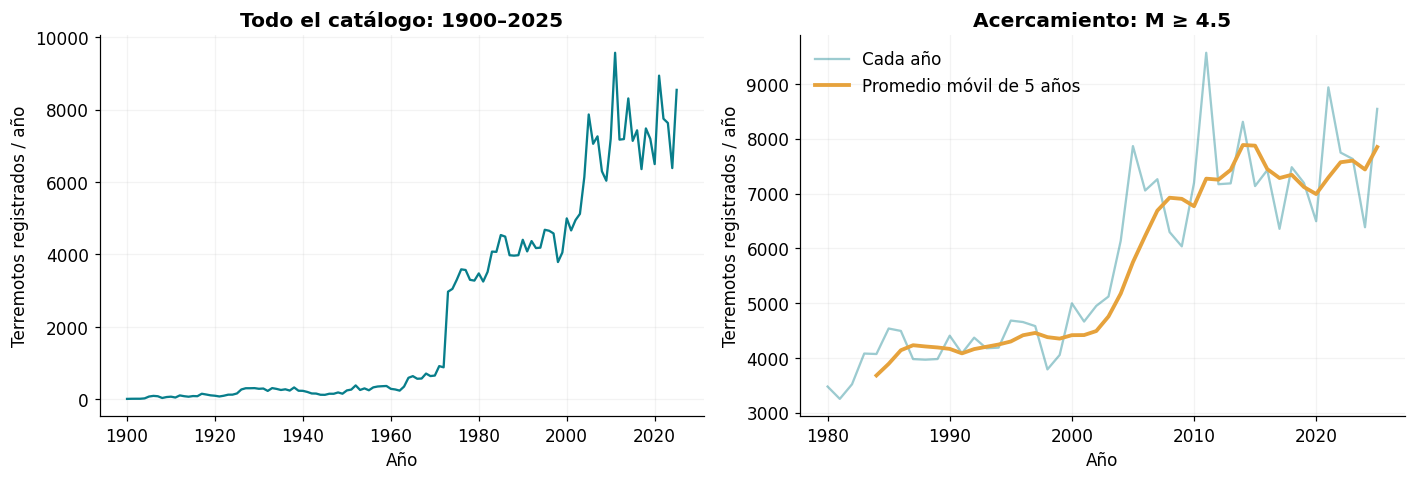

In [5]:
all_counts = full.groupby('year').size().reindex(range(1900, 2026), fill_value=0)
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
axs[0].plot(all_counts.index, all_counts, color=colors[0])
axs[0].set(title='Todo el catálogo: 1900–2025', xlabel='Año', ylabel='Terremotos registrados / año')
axs[1].plot(counts.index, counts[4.5], alpha=.4, label='Cada año')
axs[1].plot(counts.index, counts[4.5].rolling(5).mean(), lw=2.5, label='Promedio móvil de 5 años')
axs[1].set(title='Acercamiento: M ≥ 4.5', xlabel='Año', ylabel='Terremotos registrados / año')
axs[1].legend(frameon=False)
for ax in axs: ax.grid(alpha=.15)
finish('01_conteos')


Los registros crecen mucho respecto del comienzo del siglo XX, pero la serie reciente también tiene subidas y bajadas. No es un crecimiento uniforme año a año. La siguiente pregunta es si este patrón aparece igual en todas las magnitudes.


## 4. ¿La comparación cambia al subir la magnitud mínima?
Los grupos son **acumulativos**: un evento M = 7.2 está incluido en todos los umbrales. No son muestras independientes y no debemos sumar sus conteos.

Para comparar períodos de distinta duración usamos eventos por año. El último período tiene seis años y las décadas anteriores tienen diez.


In [6]:
periods = {'1980–1989': (1980, 1989), '1990–1999': (1990, 1999),
           '2000–2009': (2000, 2009), '2010–2019': (2010, 2019), '2020–2025': (2020, 2025)}
period_table = pd.DataFrame({label: counts.loc[a:b].mean()
                             for label, (a, b) in periods.items()}).T
period_table.columns = [f'M ≥ {m:g}' for m in thresholds]
display(period_table.round(1))
ratio = counts.loc[2020:2025].mean() / counts.loc[1980:1989].mean()
display(pd.DataFrame({'Razón reciente / inicial': ratio,
                      'Cambio porcentual': (ratio-1)*100}).round(2))


,M ≥ 4.5,M ≥ 5,M ≥ 5.5,M ≥ 6,M ≥ 7
1980–1989,3936.0,1575.2,425.1,125.4,11.0
1990–1999,4298.9,1457.9,483.8,152.7,15.4
2000–2009,6038.4,1718.8,514.9,158.2,14.3
2010–2019,7501.8,1836.9,489.0,149.2,16.0
2020–2025,7623.0,1800.2,464.8,132.5,14.0


,Razón reciente / inicial,Cambio porcentual
4.5,1.94,93.67
5.0,1.14,14.28
5.5,1.09,9.35
6.0,1.06,5.66
7.0,1.27,27.27


## 5. Figura clave: el aumento depende de qué terremotos contamos
En vez de dejar todo en un eje logarítmico, juntamos tres perspectivas:

- **A:** los conteos anuales muestran la variabilidad y la diferencia de tamaños entre grupos.
- **B:** dividimos el promedio móvil por el promedio de 1980–1989 de cada grupo. Un valor de 2 significa el doble de su propia referencia, no el doble que otro grupo.
- **C:** resumimos el cambio entre 1980–1989 y 2020–2025. Cada punto es una razón descriptiva, no una estimación causal ni una prueba de significancia.

Con esto podemos comparar cantidades y cambios relativos en la misma figura.


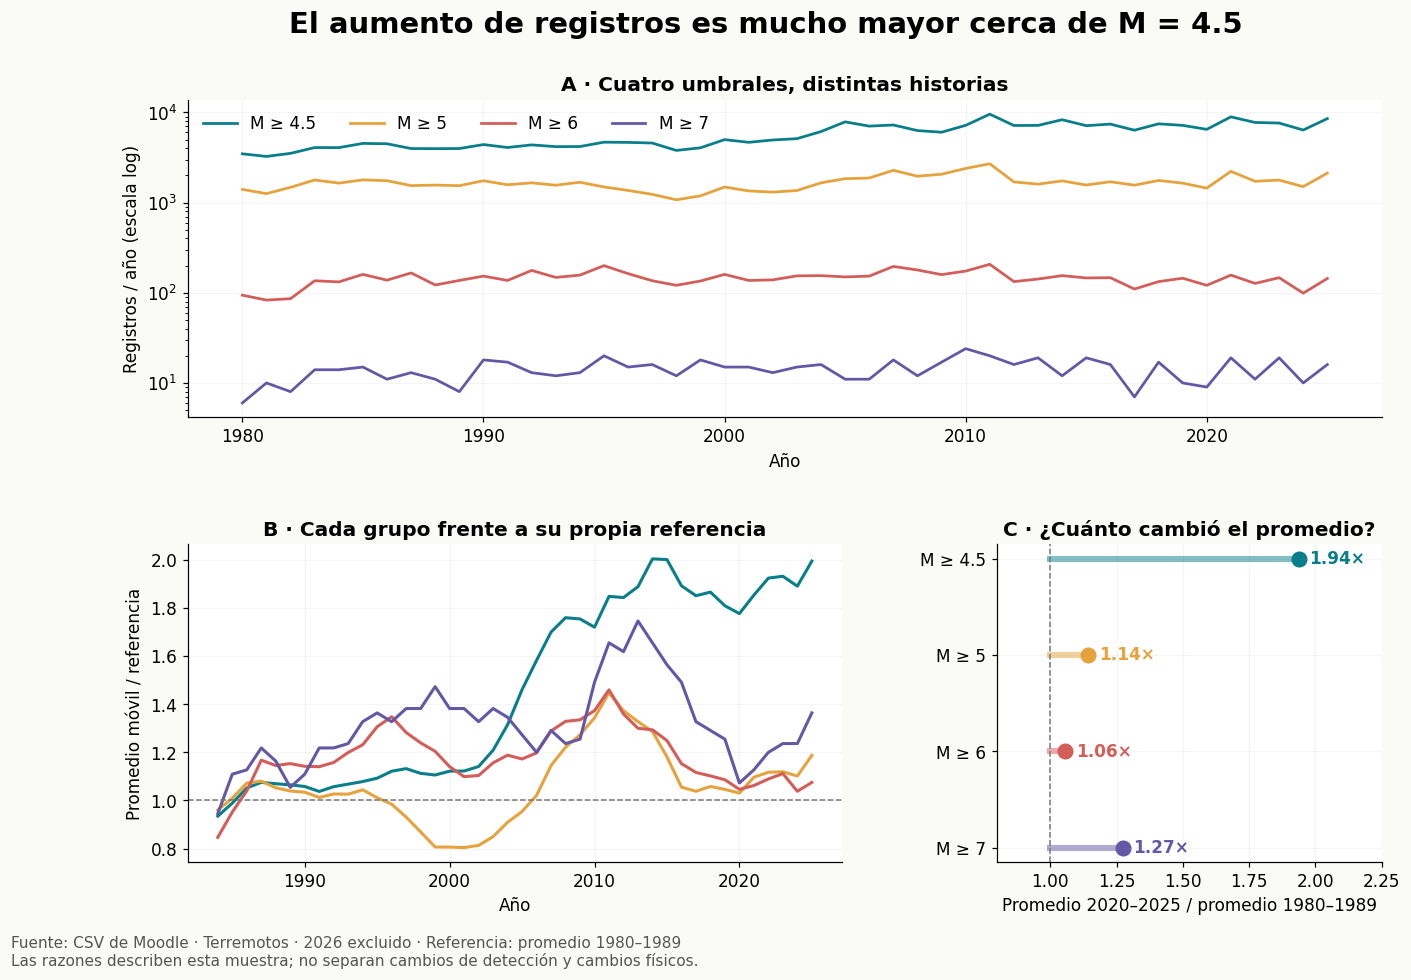

In [7]:
selected = [4.5, 5.0, 6.0, 7.0]
cs = dict(zip(selected, [colors[0], colors[1], colors[2], colors[3]]))
base = counts.loc[1980:1989].mean()
fig = plt.figure(figsize=(14, 9), facecolor='#FAFAF7')
gs = fig.add_gridspec(2, 2, width_ratios=[1.7, 1], hspace=.4, wspace=.3, top=.9, bottom=.13)
a = fig.add_subplot(gs[0, :]); b = fig.add_subplot(gs[1, 0]); c = fig.add_subplot(gs[1, 1])
for m in selected:
    a.plot(counts.index, counts[m], color=cs[m], lw=1.8, label=f'M ≥ {m:g}')
    b.plot(counts.index, counts[m].rolling(5).mean()/base[m], color=cs[m], lw=2)
a.set(yscale='log', ylabel='Registros / año (escala log)', xlabel='Año', title='A · Cuatro umbrales, distintas historias')
a.legend(ncol=4, frameon=False)
b.axhline(1, color='#777777', ls='--', lw=1)
b.set(xlabel='Año', ylabel='Promedio móvil / referencia', title='B · Cada grupo frente a su propia referencia')
for i, m in enumerate(selected):
    c.plot([1, ratio[m]], [i, i], color=cs[m], lw=4, alpha=.5)
    c.scatter(ratio[m], i, color=cs[m], s=90)
    c.text(ratio[m]+.04, i, f'{ratio[m]:.2f}×', va='center', color=cs[m], weight='bold')
c.axvline(1, color='#777777', ls='--', lw=1)
c.set(yticks=range(4), yticklabels=[f'M ≥ {m:g}' for m in selected], xlim=(.8, 2.25),
      xlabel='Promedio 2020–2025 / promedio 1980–1989', title='C · ¿Cuánto cambió el promedio?')
c.invert_yaxis()
for ax in [a,b,c]: ax.grid(alpha=.12)
fig.suptitle('El aumento de registros es mucho mayor cerca de M = 4.5', fontsize=19, weight='bold', y=.99)
fig.text(.01, .025, 'Fuente: CSV de Moodle · Terremotos · 2026 excluido · Referencia: promedio 1980–1989\nLas razones describen esta muestra; no separan cambios de detección y cambios físicos.', fontsize=10, color='#555555')
finish('02_figura_clave')


### ¿Qué nos dice?
La figura responde si la evolución depende del umbral. El cambio relativo de M ≥ 4.5 es bastante mayor que el de los umbrales altos. Aun así, sería incorrecto decir que los eventos grandes “no cambian”: fluctúan y su promedio también puede diferir entre períodos.

**Por qué es la figura clave:** conecta directamente la pregunta con una comparación controlada por magnitud. La normalización permite ver lo que cuesta comparar en conteos absolutos, pero la acompañamos con esos conteos para no ocultar que M ≥ 7 tiene muchos menos eventos.

El resultado es compatible con cambios del registro, pero esta figura por sí sola no identifica su causa. Tampoco demuestra que la tasa física sea constante.


En números: M ≥ 4.5 pasa de **3936.0 a 7623.0 eventos/año** (1.94×), mientras M ≥ 6 pasa de **125.4 a 132.5** (1.06×). Para M ≥ 7 el promedio cambia de **11 a 14** (1.27×): una diferencia de tres eventos al año tiene un porcentaje apreciable porque la referencia es pequeña.

## 6. ¿Estamos dependiendo demasiado de un período de referencia?
Hasta aquí elegimos los años ochenta como referencia. Ahora repetimos la comparación con los noventa y los dos mil. Esto es una comprobación de sensibilidad sencilla: si nuestra frase cambia mucho al mover la referencia, debemos decirlo.


,1980–1989,1990–1999,2000–2009
M ≥ 4.5,1.94,1.77,1.26
M ≥ 5,1.14,1.23,1.05
M ≥ 5.5,1.09,0.96,0.90
M ≥ 6,1.06,0.87,0.84
M ≥ 7,1.27,0.91,0.98


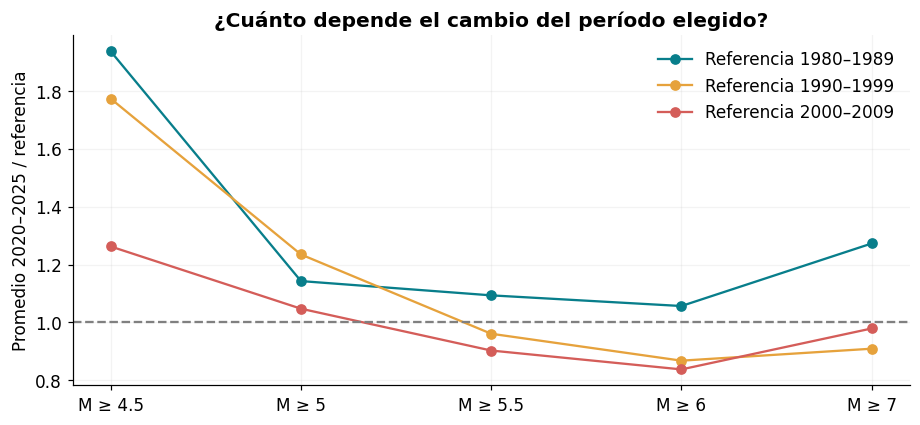

In [8]:
references = {'1980–1989': (1980,1989), '1990–1999': (1990,1999), '2000–2009': (2000,2009)}
sensitivity = pd.DataFrame({label: counts.loc[2020:2025].mean()/counts.loc[a:b].mean()
                            for label,(a,b) in references.items()})
sensitivity.index = [f'M ≥ {m:g}' for m in thresholds]
display(sensitivity.round(2))
fig, ax = plt.subplots(figsize=(8.5,4))
for i, label in enumerate(references):
    ax.plot(range(len(thresholds)), sensitivity[label], 'o-', label=f'Referencia {label}')
ax.axhline(1, color='gray', ls='--')
ax.set(xticks=range(len(thresholds)), xticklabels=sensitivity.index,
       ylabel='Promedio 2020–2025 / referencia', title='¿Cuánto depende el cambio del período elegido?')
ax.legend(frameon=False); ax.grid(alpha=.15)
finish('03_sensibilidad')


Este gráfico permite distinguir dos afirmaciones: que los registros aumentaron respecto de una década concreta y que existe un crecimiento sostenido. No son equivalentes. Si una razón baja de 1 al cambiar la referencia, el promedio reciente es menor que el de esa otra ventana; eso no contradice la primera comparación.


Aquí se ve el efecto concreto: para M ≥ 7 la razón es **1.27** usando los ochenta, pero **0.91** usando los noventa y **0.98** usando los dos mil. En cambio, M ≥ 4.5 sigue por encima de 1 con las tres referencias (**1.94, 1.77 y 1.26**). La magnitud del cambio depende del período, aunque el contraste entre umbrales persiste.

### ¿Qué pasa entre los umbrales?
Para mirar toda la distribución dividimos la magnitud en intervalos de 0.2. A la izquierda mostramos eventos por año; a la derecha, el porcentaje de cada período. Los intervalos tienen el mismo ancho, así que las alturas son comparables. El panel de proporciones deja de mostrar el tamaño total de la muestra.


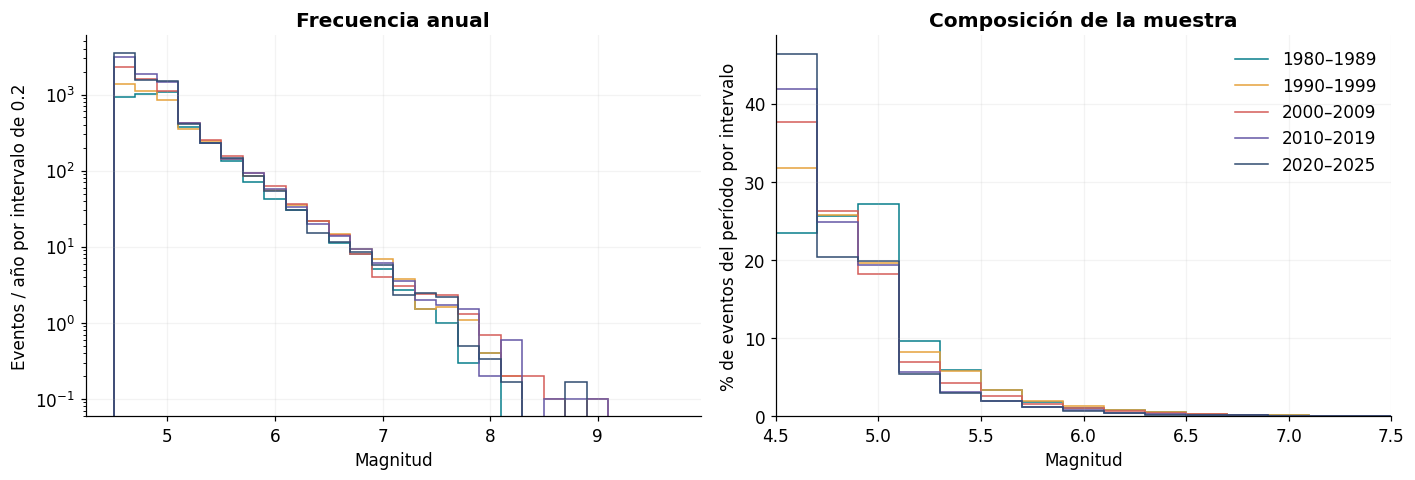

In [9]:
bins = np.arange(4.5, 9.71, .2)
fig, axs = plt.subplots(1,2,figsize=(13,4.5))
for label,(a,b) in periods.items():
    values = recent.loc[recent.year.between(a,b) & (recent.mag>=4.5), 'mag']
    h,_ = np.histogram(values,bins=bins)
    axs[0].stairs(h/(b-a+1), bins, label=label)
    axs[1].stairs(h/h.sum()*100, bins, label=label)
axs[0].set(yscale='log', xlabel='Magnitud', ylabel='Eventos / año por intervalo de 0.2', title='Frecuencia anual')
axs[1].set(xlabel='Magnitud', ylabel='% de eventos del período por intervalo', title='Composición de la muestra', xlim=(4.5,7.5))
axs[1].legend(frameon=False)
for ax in axs: ax.grid(alpha=.15)
finish('04_distribucion_magnitud')


Al separar frecuencia y proporción podemos preguntar si una década tiene simplemente más registros o si además concentra una fracción distinta cerca del límite inferior. Los ceros del panel logarítmico no se representan; no significan magnitudes físicamente imposibles.


La diferencia entre períodos se concentra sobre todo cerca de M = 4.5–5. A magnitudes mayores las curvas de frecuencia anual se acercan mucho más. En proporciones, los períodos recientes dan más peso a los intervalos próximos al límite inferior; por eso la composición también importa.

### Una vista completa de año y magnitud
El mapa de calor cuenta eventos por año e intervalo de magnitud. Usamos `log10(N + 1)` para que los intervalos menos poblados sigan siendo visibles. Aquí cero sí tiene una representación explícita.


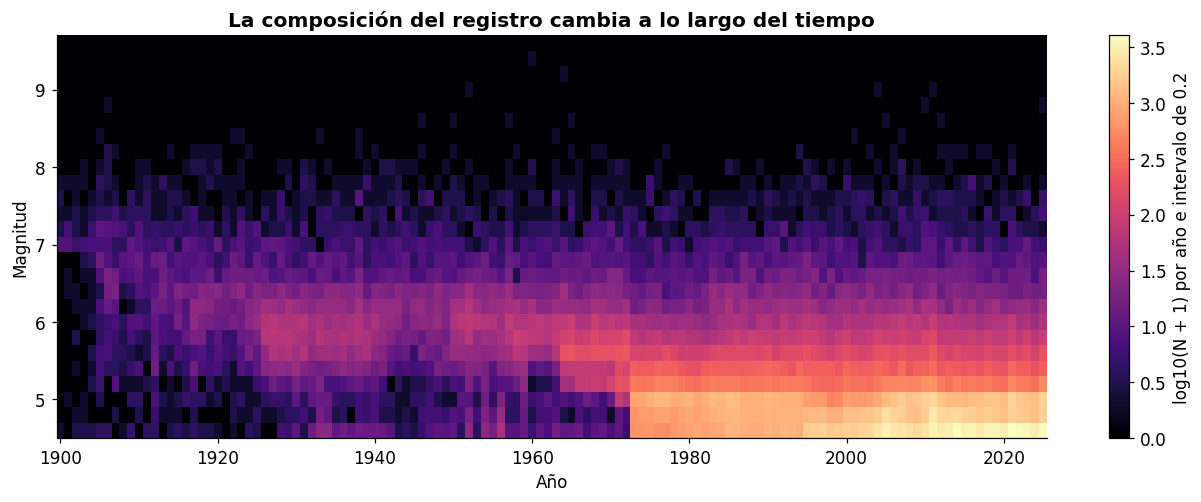

In [10]:
data = full[full.mag>=4.5]
H, xe, ye = np.histogram2d(data.year, data.mag,
                          bins=[np.arange(1899.5,2026.5), np.arange(4.5,9.71,.2)])
fig, ax = plt.subplots(figsize=(12,4.7))
im = ax.pcolormesh(xe,ye,np.log10(H.T+1),cmap='magma',shading='auto')
fig.colorbar(im,ax=ax,label='log10(N + 1) por año e intervalo de 0.2')
ax.set(xlabel='Año',ylabel='Magnitud',title='La composición del registro cambia a lo largo del tiempo')
finish('05_mapa_temporal')


Las primeras décadas tienen muchos menos registros moderados. Esto muestra una diferencia de composición histórica. La interpretación de incompletitud necesita contexto sobre las redes y la selección del archivo: no calculamos aquí una magnitud de completitud ni reconstruimos eventos ausentes.


## 7. ¿El catálogo mide y reporta siempre de la misma forma?
Ahora incorporamos información del propio registro. Agrupamos por década para comparar el porcentaje de faltantes y la mezcla de `magType`. Incluimos solo hasta 2025; la última década es parcial y está etiquetada como tal.

`magType` distingue formas de estimar magnitud. No convertimos todas las escalas en una sola ni asumimos que un mismo valor sea perfectamente intercambiable entre ellas.


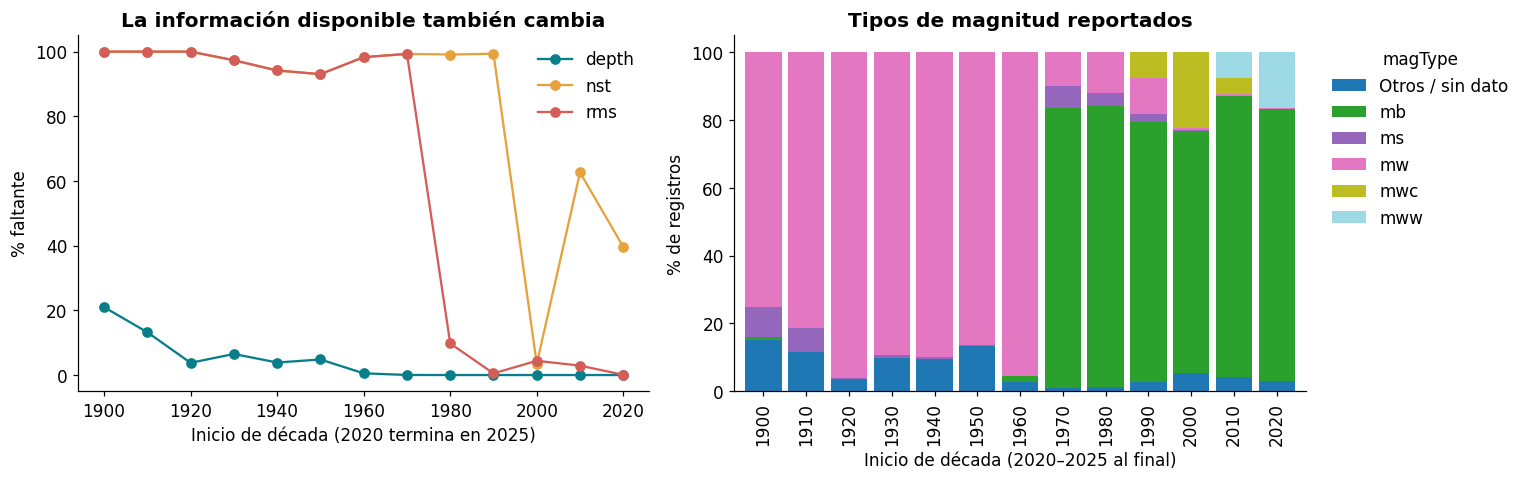

,Registros por fuente
net,
us,283454
iscgem,15378
iscgemsup,1789
ak,1183
ci,956
ushis,824
nc,435
hv,210


In [11]:
audit = full.copy()
audit['decade'] = audit.year//10*10
missing_dec = audit.groupby('decade')[['depth','nst','rms']].agg(lambda s: s.isna().mean()*100)
top_types = audit.magType.value_counts().head(5).index
audit['tipo_agrupado'] = audit.magType.fillna('Sin dato').where(audit.magType.isin(top_types),'Otros / sin dato')
type_mix = pd.crosstab(audit.decade,audit.tipo_agrupado,normalize='index')*100
fig,axs = plt.subplots(1,2,figsize=(14,4.5))
for col in missing_dec:
    axs[0].plot(missing_dec.index,missing_dec[col],'o-',label=col)
axs[0].set(xlabel='Inicio de década (2020 termina en 2025)',ylabel='% faltante',title='La información disponible también cambia')
axs[0].legend(frameon=False)
type_mix.plot.bar(stacked=True,ax=axs[1],width=.85,colormap='tab20')
axs[1].set(xlabel='Inicio de década (2020–2025 al final)',ylabel='% de registros',title='Tipos de magnitud reportados')
axs[1].legend(title='magType',bbox_to_anchor=(1.02,1),frameon=False)
finish('06_heterogeneidad')
display(audit['net'].value_counts().head(8).rename('Registros por fuente').to_frame())


Los faltantes y los tipos de magnitud cambian con el tiempo: no estamos trabajando con una colección homogénea de mediciones. Eso agrega una limitación a la comparación temporal. Tampoco podemos interpretar automáticamente un cambio de `magType` como una mejora o un empeoramiento de calidad.

`nst` no es el número total de estaciones operativas en el planeta, y `rms` no es una incertidumbre de profundidad. Sería incorrecto usarlos de esa forma para “corregir” los conteos.


Un ejemplo concreto es el predominio de `mw` en varias décadas antiguas y de `mb` desde los setenta. Los faltantes de `nst` son muy altos al comienzo y su comportamiento reciente tampoco es uniforme. No conviene interpretar todas las décadas como si tuvieran el mismo esquema de medición.

## 8. ¿La profundidad agrega otra historia?
Usamos tres grupos operativos: superficial (<70 km), intermedia (70–300 km) y profunda (>300 km). Separamos los valores negativos para no confundirlos con profundidades positivas en los histogramas. No interpolamos ni rellenamos profundidades ausentes.

Primero vemos la distribución, y después comparamos la evolución dentro de cada grupo para M ≥ 4.5 y M ≥ 6. Así cambiamos una tercera variable sin abandonar la pregunta temporal.


,n,mediana_M,mediana_km
grupo,,,
Superficial,203525,4.8,26.30
Intermedia,46392,4.7,121.40
Profunda,13445,4.7,538.15


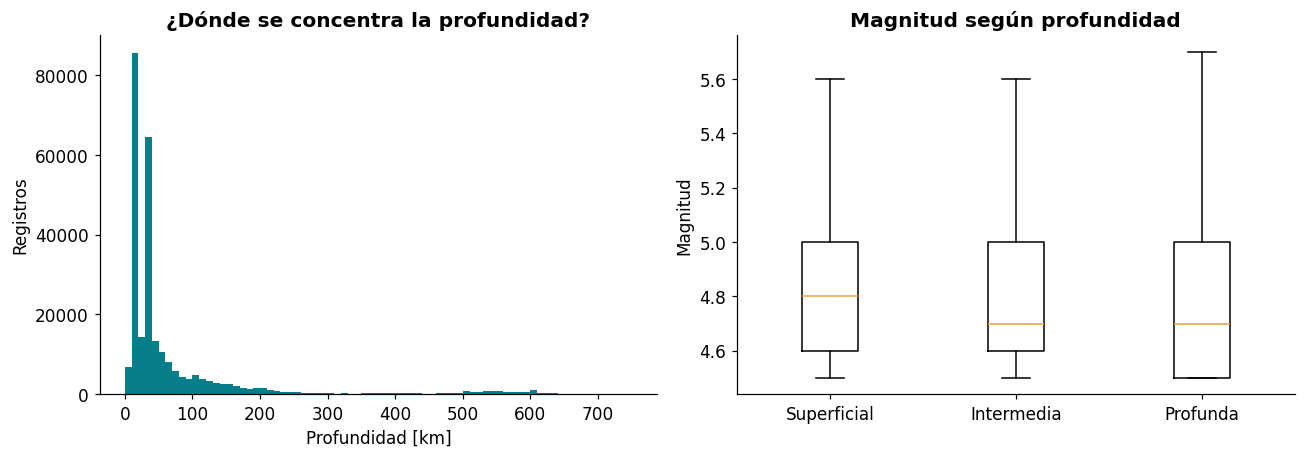

In [12]:
depth_data = recent.loc[recent.depth.notna() & (recent.depth>=0) & (recent.mag>=4.5)].copy()
def depth_class(s):
    return np.select([s<70,s<=300],['Superficial','Intermedia'],default='Profunda')
depth_data['grupo'] = depth_class(depth_data.depth)
groups = ['Superficial','Intermedia','Profunda']
display(depth_data.groupby('grupo').agg(n=('mag','size'),mediana_M=('mag','median'),
                                      mediana_km=('depth','median')).reindex(groups))
fig,axs = plt.subplots(1,2,figsize=(12,4.3))
axs[0].hist(depth_data.depth,bins=np.arange(0,751,10),color=colors[0])
axs[0].set(xlabel='Profundidad [km]',ylabel='Registros',title='¿Dónde se concentra la profundidad?')
axs[1].boxplot([depth_data.loc[depth_data.grupo.eq(g),'mag'] for g in groups],tick_labels=groups,showfliers=False)
axs[1].set(ylabel='Magnitud',title='Magnitud según profundidad')
finish('07_profundidad')


Las cajas muestran mediana y rango intercuartílico; ocultamos los puntos externos solo para que la figura se lea mejor, sin eliminarlos de los datos. Esta comparación describe el centro de la distribución, no los eventos extremos ni una relación causal.


Las medianas de magnitud son cercanas: **4.8** en superficiales y **4.7** en intermedios y profundos. Las cajas se superponen bastante. Por lo tanto, la magnitud sola no parece separar claramente estas categorías; el contexto espacial puede aportar más información.

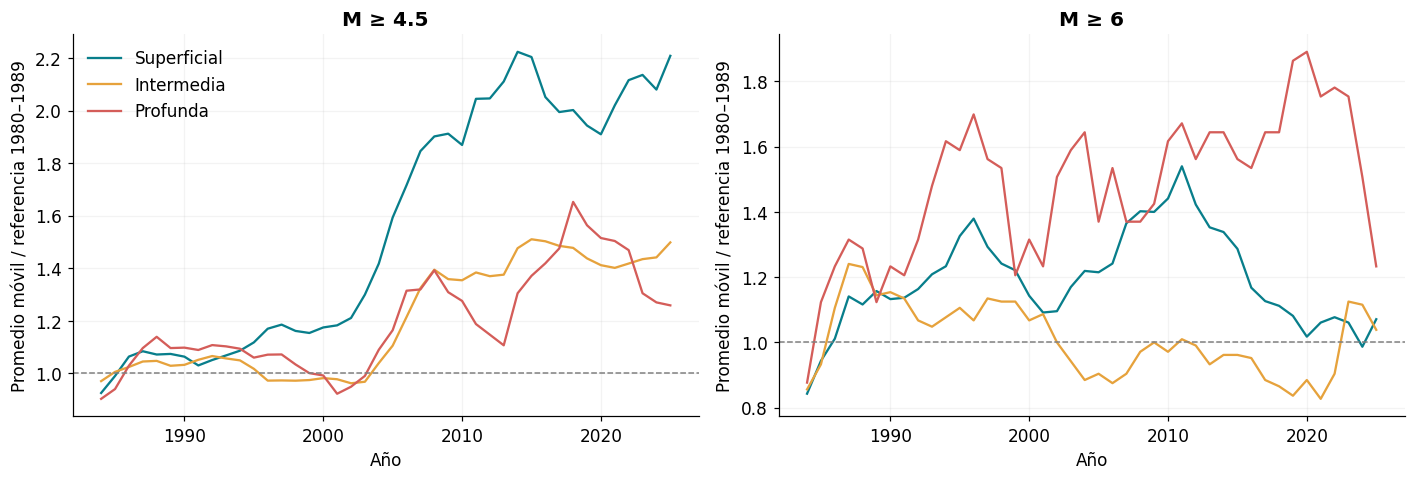

,Umbral,Grupo,Inicial / año,Reciente / año,Razón
0,4.5,Superficial,2845.8,6087.50,2.14
1,4.5,Intermedia,836.2,1225.67,1.47
2,4.5,Profunda,247.5,309.67,1.25
3,6.0,Superficial,97.3,101.17,1.04
4,6.0,Intermedia,20.8,21.83,1.05
5,6.0,Profunda,7.3,9.50,1.30


In [13]:
fig,axs = plt.subplots(1,2,figsize=(13,4.5))
depth_ratios=[]
for ax,m in zip(axs,[4.5,6.0]):
    for g in groups:
        s=annual(depth_data[depth_data.grupo.eq(g)],m,years)
        reference=s.loc[1980:1989].mean()
        ax.plot(years,s.rolling(5).mean()/reference,label=g)
        depth_ratios.append({'Umbral':m,'Grupo':g,'Inicial / año':reference,
                             'Reciente / año':s.loc[2020:2025].mean(),
                             'Razón':s.loc[2020:2025].mean()/reference})
    ax.axhline(1,color='gray',ls='--',lw=1)
    ax.set(title=f'M ≥ {m:g}',xlabel='Año',ylabel='Promedio móvil / referencia 1980–1989')
    ax.grid(alpha=.15)
axs[0].legend(frameon=False)
finish('08_tiempo_profundidad')
display(pd.DataFrame(depth_ratios).round(2))


Esta tabla y sus curvas permiten ver si un cambio global está repartido entre profundidades. La comparación está condicionada a tener profundidad reportada y no negativa. Como la disponibilidad de profundidad también cambia, no podemos atribuir las diferencias solo a procesos físicos.


Para M ≥ 4.5, la razón reciente/inicial es **2.14** en superficiales, **1.47** en intermedios y **1.25** en profundos. El aumento no se reparte por igual. Al exigir M ≥ 6, las razones son **1.04, 1.05 y 1.30**, respectivamente; en el grupo profundo hablamos de **7.3 a 9.5 eventos/año**, por lo que hay que mirar también el tamaño absoluto.

## 9. ¿El patrón global aparece en todas las regiones?
Definimos tres ventanas geográficas **antes de comparar sus series**. Son recortes ilustrativos, no países ni placas tectónicas. No tienen la misma área, así que no compararemos sus conteos como una tasa por superficie.

| Ventana | Latitud | Longitud |
|---|---|---|
| Margen de Sudamérica | −60 a 15° | −85 a −60° |
| Entorno de Japón | 25 a 50° | 125 a 150° |
| Pacífico suroccidental | −40 a −10° | 165 a 180°, y −180 a −170° |

En la última ventana hay que cruzar el meridiano de ±180°. Usamos una condición “o” para no dejar fuera un lado del mapa. El resto del mundo queda fuera de esta comparación regional, pero sigue incluido en el análisis global.


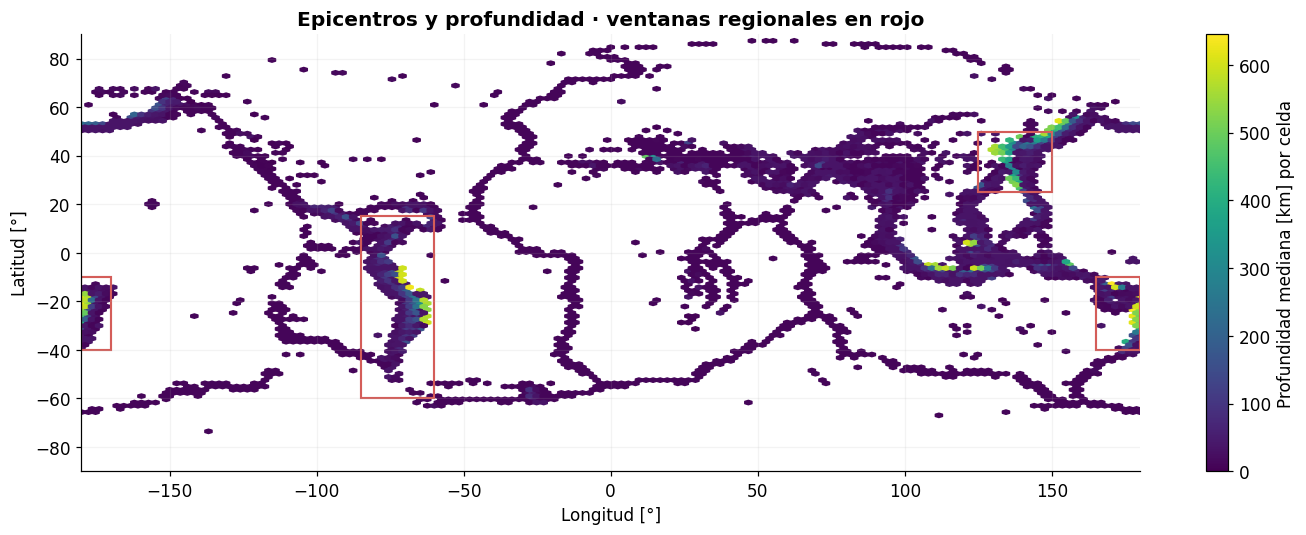

In [14]:
def region_masks(d):
    return {'Margen de Sudamérica': d.latitude.between(-60,15)&d.longitude.between(-85,-60),
            'Entorno de Japón': d.latitude.between(25,50)&d.longitude.between(125,150),
            'Pacífico suroccidental': d.latitude.between(-40,-10)&((d.longitude>=165)|(d.longitude<=-170))}
regions = region_masks(recent)
sp = depth_data
fig,ax = plt.subplots(figsize=(13,5))
hb=ax.hexbin(sp.longitude,sp.latitude,C=sp.depth,reduce_C_function=np.median,
             gridsize=(150,65),mincnt=3,cmap='viridis')
fig.colorbar(hb,ax=ax,label='Profundidad mediana [km] por celda')
from matplotlib.patches import Rectangle
for x,y,w,h in [(-85,-60,25,75),(125,25,25,25),(165,-40,15,30),(-180,-40,10,30)]:
    ax.add_patch(Rectangle((x,y),w,h,fill=False,edgecolor='#D45D59',lw=1.4))
ax.set(xlim=(-180,180),ylim=(-90,90),xlabel='Longitud [°]',ylabel='Latitud [°]',
       title='Epicentros y profundidad · ventanas regionales en rojo')
ax.grid(alpha=.15)
finish('09_espacio')


El color representa profundidad mediana, no densidad de eventos. Una celda vacía puede tener pocos eventos o ninguno: no significa ausencia de riesgo. La estructura espacial que aparece motiva la propuesta de ML de más adelante.


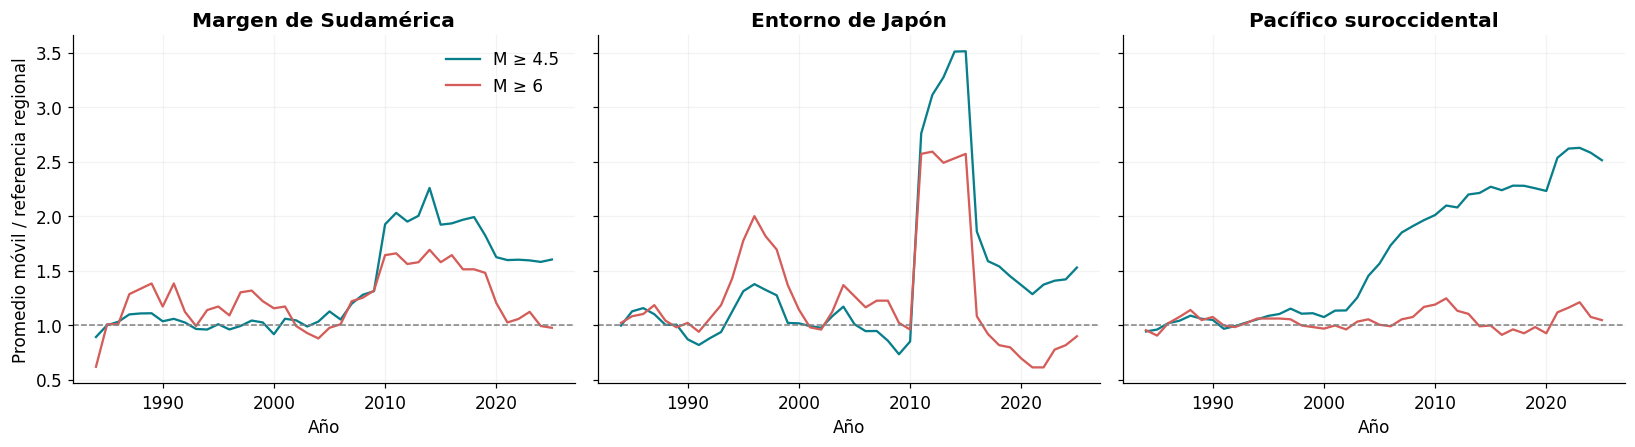

,Región,M mínima,1980–1989 / año,2020–2025 / año,Razón
0,Margen de Sudamérica,4.5,344.3,552.83,1.61
1,Margen de Sudamérica,6.0,12.3,12.33,1.00
2,Entorno de Japón,4.5,370.7,542.17,1.46
3,Entorno de Japón,6.0,9.8,8.50,0.87
4,Pacífico suroccidental,4.5,639.0,1549.00,2.42
5,Pacífico suroccidental,6.0,28.1,27.50,0.98


In [15]:
fig,axs=plt.subplots(1,3,figsize=(15,4.2),sharey=True)
regional_rows=[]
for ax,(name,mask) in zip(axs,regions.items()):
    for m,color in [(4.5,colors[0]),(6.0,colors[2])]:
        s=annual(recent[mask],m,years); ref=s.loc[1980:1989].mean()
        ax.plot(years,s.rolling(5).mean()/ref,color=color,label=f'M ≥ {m:g}')
        regional_rows.append({'Región':name,'M mínima':m,'1980–1989 / año':ref,
                              '2020–2025 / año':s.loc[2020:2025].mean(),
                              'Razón':s.loc[2020:2025].mean()/ref})
    ax.axhline(1,color='gray',ls='--',lw=1); ax.set(title=name,xlabel='Año'); ax.grid(alpha=.15)
axs[0].set_ylabel('Promedio móvil / referencia regional')
axs[0].legend(frameon=False)
finish('10_regiones')
display(pd.DataFrame(regional_rows).round(2))


Cada curva usa la referencia de su propia región. Así comparamos evolución relativa, no cuál región “tiembla más”. Los recortes, la mezcla de redes y las secuencias sísmicas pueden influir en los resultados. Tres ventanas tampoco representan por sí solas todas las regiones del planeta.


En M ≥ 4.5, las razones son **1.61** para Sudamérica, **1.46** para Japón y **2.42** para el Pacífico suroccidental. En M ≥ 6 pasan a **1.00, 0.87 y 0.98**. En estas tres ventanas aparece el contraste global entre umbrales, aunque la intensidad del cambio es distinta y Japón presenta un pico muy marcado en la serie.

## 10. ¿Un año excepcional significa una tendencia?
Tomamos el año con más registros M ≥ 4.5 en 1980–2025 y vemos cómo se reparte por mes. Lo comparamos con la mediana mensual de los demás años. Excluimos el año seleccionado de esa referencia para no compararlo parcialmente consigo mismo.

Este es un análisis exploratorio elegido después de mirar los datos; no es una prueba estadística de anomalías. Contamos por mes sin corregir por su duración, por lo que no buscamos estacionalidad.


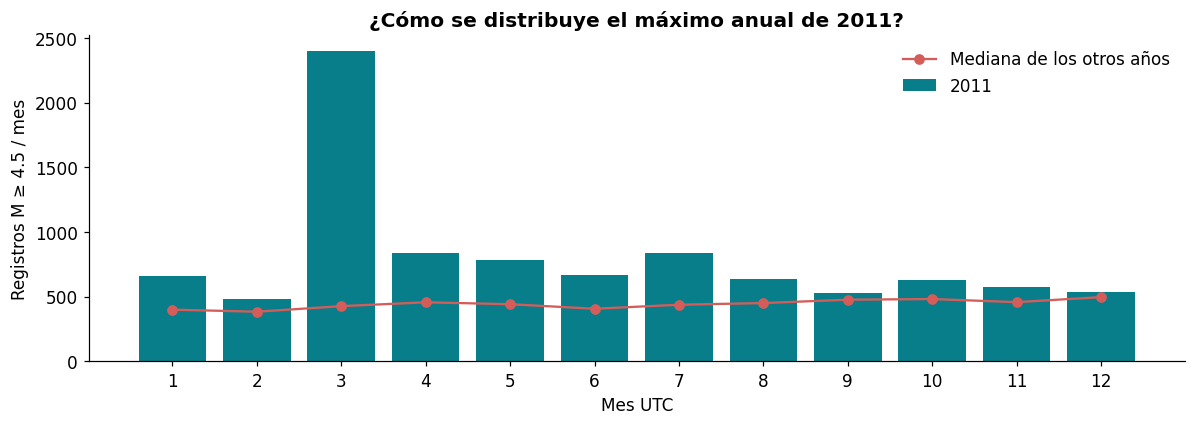

Año seleccionado: 2011; registros M ≥ 4.5: 9,568


,time,mag,place
193304,2011-03-11 05:46:24.120000+00:00,9.1,"2011 Great Tohoku Earthquake, Japan"
193319,2011-03-11 06:15:40.280000+00:00,7.9,"47 km E of ?arai, Japan"
193324,2011-03-11 06:25:50.300000+00:00,7.7,"272 km ESE of Kamaishi, Japan"
197883,2011-07-06 19:03:18.260000+00:00,7.6,Kermadec Islands region
200167,2011-10-21 17:57:16.100000+00:00,7.4,Kermadec Islands region


In [16]:
peak_year=int(counts[4.5].idxmax())
monthly=pd.crosstab(recent.loc[recent.mag>=4.5,'year'],recent.loc[recent.mag>=4.5,'month']).reindex(index=years,columns=range(1,13),fill_value=0)
reference=monthly.drop(index=peak_year).median()
fig,ax=plt.subplots(figsize=(11,4))
ax.bar(np.arange(1,13),monthly.loc[peak_year],color=colors[0],label=str(peak_year))
ax.plot(range(1,13),reference,'o-',color=colors[2],label='Mediana de los otros años')
ax.set(xticks=range(1,13),xlabel='Mes UTC',ylabel='Registros M ≥ 4.5 / mes',title=f'¿Cómo se distribuye el máximo anual de {peak_year}?')
ax.legend(frameon=False);finish('11_anio_excepcional')
print(f'Año seleccionado: {peak_year}; registros M ≥ 4.5: {counts.loc[peak_year,4.5]:,}')
display(recent[recent.year.eq(peak_year)].nlargest(5,'mag')[['time','mag','place']])


Si el exceso se concentra en ciertos meses, eso sugiere investigar episodios o secuencias concretas. La coincidencia con eventos grandes es una pista, pero para identificar réplicas necesitaríamos un análisis espacio-temporal y criterios de asociación. No tratamos todas las filas como observaciones físicamente independientes ni interpretamos un pico como una tendencia sostenida.


El máximo corresponde a **2011, con 9568 registros** M ≥ 4.5. Solo marzo reúne **2401**, aproximadamente el **25.1%** del año. En la tabla de los mayores eventos aparece el terremoto de Tohoku de marzo de 2011. Es una coincidencia temporal relevante, pero no basta para etiquetar todos los eventos de marzo como réplicas.

## 11. Algo inesperado: ¿por qué tantas profundidades son exactamente iguales?
Un histograma amplio puede esconderlo. Ahora contamos los valores exactos más frecuentes, sin redondearlos previamente. Nos quedamos con la muestra reciente M ≥ 4.5 y profundidad no negativa para mantener el mismo recorte.


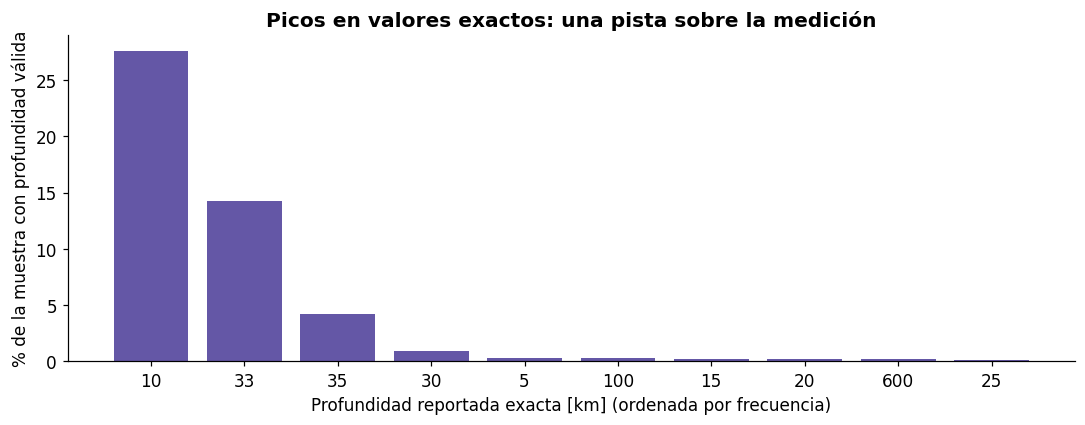

,Registros,%
depth,,
10.0,72712,27.61
33.0,37564,14.26
35.0,10992,4.17
30.0,2442,0.93
5.0,815,0.31
100.0,682,0.26
15.0,543,0.21
20.0,539,0.20
600.0,485,0.18


Además hay 133 profundidades negativas; mínimo: -3.0 km


,time,depth,mag,place,net
77019,1988-11-30 10:15:19.660000+00:00,-3.0,4.9,"37 km SSE of Nelchina, Alaska",ak
77530,1989-01-15 04:16:16.780000+00:00,-3.0,4.8,"167 km SE of Chignik, Alaska",ak
77756,1989-02-06 22:23:16.070000+00:00,-3.0,4.9,"20 km S of Karluk, Alaska",ak
79688,1989-08-06 15:14:48.020000+00:00,-3.0,4.8,"81 km NW of Yakutat, Alaska",ak
91038,1992-04-27 21:31:07.410000+00:00,-3.0,4.7,"80 km NE of Lime Village, Alaska",ak


In [17]:
common_depths=depth_data.depth.value_counts().head(10)
fig,ax=plt.subplots(figsize=(10,4))
ax.bar([f'{v:g}' for v in common_depths.index],common_depths.values/len(depth_data)*100,color=colors[3])
ax.set(xlabel='Profundidad reportada exacta [km] (ordenada por frecuencia)',ylabel='% de la muestra con profundidad válida',
       title='Picos en valores exactos: una pista sobre la medición')
finish('12_profundidades_repetidas')
display(pd.DataFrame({'Registros':common_depths,'%':common_depths/len(depth_data)*100}).round(2))
negative=eq[eq.depth<0]
print(f'Además hay {len(negative)} profundidades negativas; mínimo: {negative.depth.min()} km')
display(negative.nsmallest(5,'depth')[['time','depth','mag','place','net']])


### Observación
Hay una concentración marcada en profundidades exactas, especialmente 10 y 33 km. También existen profundidades negativas en el archivo completo.

### Hipótesis
Los picos pueden reflejar profundidades fijadas o redondeadas en el procesamiento, además de la distribución física. La documentación del USGS describe el uso de profundidades fijadas cuando la información disponible no permite restringirlas bien. Eso hace plausible la explicación, pero no identifica cuáles registros individuales fueron fijados.

Para las profundidades negativas, el datum y la incertidumbre de localización pueden importar; el signo por sí solo no basta para declarar un error.

### Evidencia adicional
Necesitaríamos incertidumbres de profundidad, indicadores de parámetros fijados, metodología de cada red y datum de referencia. No eliminamos todos los 10 o 33 km: borraríamos una parte grande de la muestra sin saber qué registros están afectados.

**Nueva pregunta:** ¿cambia la frecuencia de estas profundidades exactas entre redes y épocas? Sería una continuación útil antes de usar profundidad como etiqueta de un modelo.


En este recorte, **27.61%** de los eventos con profundidad válida tienen exactamente 10 km y **14.26%** exactamente 33 km: juntos suman cerca de **41.9%**. El tamaño de esta concentración hace que el detalle sea relevante para interpretar la distribución y para pensar en las etiquetas de ML.

## 12. Exploración interactiva: cambiar el umbral y la forma de comparar
Aquí usamos **Plotly** para explorar los mismos conteos de la figura clave. Puedes:

- cambiar entre conteos y valores relativos a 1980–1989;
- pasar el cursor para leer el año y el valor exacto;
- ocultar una curva haciendo clic en su leyenda;
- mover el control inferior para acercarte a un intervalo.

El recorte visual no recalcula la referencia: siempre sigue siendo 1980–1989. Exportamos además un HTML autónomo, con la biblioteca incluida, para abrirlo sin conexión. Si Colab no muestra la salida guardada, vuelve a ejecutar esta celda. Si no está instalado Plotly, ejecuta primero `%pip install plotly` en una celda aparte.


Los botones de escala permiten separar las curvas de menor frecuencia. Todos los conteos de estos umbrales son positivos en esta ventana, por lo que la escala logarítmica es utilizable.

In [18]:
import plotly.graph_objects as go

interactive=go.Figure()
for m in selected:
    interactive.add_trace(go.Scatter(x=years,y=counts[m].values,mode='lines',
        name=f'M ≥ {m:g}',line=dict(color=cs[m],width=2),
        hovertemplate='%{x}: %{y:,.2f}<extra>%{fullData.name}</extra>'))
raw_y=[counts[m].tolist() for m in selected]
relative_y=[(counts[m]/base[m]).tolist() for m in selected]
interactive.update_layout(template='plotly_white',height=620,
    title='Explora el catálogo · magnitud y evolución temporal',
    yaxis_title='Registros / año',xaxis_title='Año',
    legend=dict(orientation='h',y=1.08),margin=dict(t=145,b=60),
    updatemenus=[dict(type='buttons',direction='right',x=0,y=1.25,
        buttons=[dict(label='Conteos anuales',method='update',
                      args=[{'y':raw_y},{'yaxis.title.text':'Registros / año'}]),
                 dict(label='Respecto de 1980–1989',method='update',
                      args=[{'y':relative_y},{'yaxis.title.text':'Conteo anual / referencia 1980–1989'}])])])
interactive.update_layout(updatemenus=list(interactive.layout.updatemenus) + [dict(type='buttons', direction='right', x=.65, y=1.25, buttons=[dict(label='Escala lineal', method='relayout', args=[{'yaxis.type':'linear'}]), dict(label='Escala log', method='relayout', args=[{'yaxis.type':'log'}])])])
interactive.update_xaxes(rangeslider_visible=True,range=[1980,2025])
interactive.write_html(OUT/'explorador_terremotos.html',include_plotlyjs=True,full_html=True)
# HTML conserva los controles en Jupyter y Colab, sin un servidor adicional.
from IPython.display import HTML
html=interactive.to_html(include_plotlyjs=True,full_html=False)
display(HTML(html))


## 13. Respuesta al desafío inicial
### ¿Podemos afirmar que últimamente está temblando más?
**Con este archivo no podemos afirmarlo como un aumento físico global.** Sí podemos cuantificar cómo cambian los registros y cuánto depende la comparación del umbral y del período.

La evidencia central es que el aumento relativo es mayor cerca del límite inferior del catálogo. Las ventanas de referencia, profundidad y región permiten revisar cuánto cambia esa lectura al agregar contexto. Además, el tipo de magnitud y la disponibilidad de información no son constantes en el tiempo.

Eso es compatible con cambios de cobertura y procesamiento. Como contexto externo, el USGS explica que una mayor instrumentación contribuye al aumento de eventos registrados en ComCat. Sin embargo, nuestro EDA no separa cuantitativamente ese efecto de variaciones físicas, secuencias sísmicas o criterios de selección del CSV.

Tampoco demostramos ausencia de cambios: no realizamos una prueba de tendencia con un modelo de dependencia temporal y un catálogo homogéneo. “No podemos concluir un aumento global” es distinto de “demostramos que todo sigue igual”.


In [19]:
# Resumen calculado: evita copiar cifras que puedan quedar desactualizadas.
for m in selected:
    initial=counts.loc[1980:1989,m].mean(); last=counts.loc[2020:2025,m].mean()
    print(f'M ≥ {m:g}: {initial:.1f} → {last:.1f} eventos/año; razón {last/initial:.2f}×')
counts.to_csv(OUT/'conteos_anuales.csv')
pd.DataFrame(regional_rows).to_csv(OUT/'comparacion_regional.csv',index=False)


M ≥ 4.5: 3936.0 → 7623.0 eventos/año; razón 1.94×
M ≥ 5: 1575.2 → 1800.2 eventos/año; razón 1.14×
M ≥ 6: 125.4 → 132.5 eventos/año; razón 1.06×
M ≥ 7: 11.0 → 14.0 eventos/año; razón 1.27×


## 14. Posible problema de Machine Learning
**Propuesta:** predecir la categoría de profundidad de un evento registrado: superficial, intermedia o profunda. Es una **clasificación multiclase**, porque la salida es una categoría.

Usaríamos latitud, longitud y magnitud como punto de partida. La estructura espacial del EDA sugiere que hay información útil. `depth` no puede entrar como feature: de ella sale directamente la etiqueta. Tampoco usaríamos `place` como si fuera una medición independiente de las coordenadas.

La aplicación sería exploratoria, para estimar la categoría de profundidad de un evento ya detectado a partir de su ubicación y magnitud. No predice cuándo ocurrirá un terremoto.

Antes de entrenar habría que considerar:

- **Desbalance:** comparar con la regla de predecir siempre la clase mayoritaria y revisar métricas por clase, no solo accuracy.
- **Etiquetas:** profundidades faltantes, negativas o posiblemente fijadas requieren una decisión explícita. Para esta propuesta empezaríamos por profundidades no negativas reportadas y estudiaríamos la sensibilidad a valores fijados.
- **Dependencia:** eventos cercanos pueden pertenecer a la misma secuencia. Una división aleatoria puede dar una impresión demasiado optimista.
- **Generalización:** reservar períodos posteriores o bloques espaciales para evaluar qué tan bien funciona fuera de la muestra de entrenamiento.
- **Coordenadas:** −180° y 180° son vecinos; su tratamiento numérico debe respetar esa continuidad.
- **Cambios de medición:** año, red y `magType` podrían capturar prácticas del catálogo. No los incluiríamos automáticamente como señal física.

No entrenamos ningún modelo, tal como pide la pauta.

## 15. Conclusión
El catálogo muestra más registros recientes, pero la magnitud mínima cambia mucho la comparación. La figura clave reúne conteos y cambios relativos para mostrar esa diferencia sin esconder el tamaño de las muestras. Cambiar la referencia temporal y separar por profundidad o región ayuda a evitar una lectura única del total global.

También encontramos señales de heterogeneidad: cambian los tipos de magnitud y los faltantes, y aparecen concentraciones en profundidades exactas. En conjunto, el análisis permite describir cómo cambia el catálogo, pero no convertir ese cambio directamente en un aumento físico global de terremotos.

Para la presentación oral usaría la figura clave, una figura de contexto y las profundidades repetidas. El interactivo sirve para explorar preguntas durante la exposición, sin que la conclusión dependa de poder usarlo.

## Referencias y contexto
Los cálculos y figuras provienen del CSV de Moodle. Las siguientes fuentes se usan para interpretar variables y limitaciones, no para reemplazar los resultados del análisis:

- [USGS — Documentación de ComCat](https://earthquake.usgs.gov/data/comcat/): definición de campos y heterogeneidad del catálogo.
- [USGS — ¿Está aumentando la actividad sísmica?](https://www.usgs.gov/faqs/why-are-we-having-so-many-or-so-few-earthquakes-has-naturally-occurring-earthquake-activity): contexto sobre instrumentación y registros.
- [USGS — Profundidades cero y negativas](https://www.usgs.gov/faqs/what-does-it-mean-earthquake-occurred-a-depth-0-km-how-can-earthquake-have-a-negative-depth): referencia de profundidad y localización.
- [USGS — Profundidad de los terremotos](https://www.usgs.gov/programs/earthquake-hazards/determining-depth-earthquake): limitaciones al determinar profundidad.
- [Plotly — Controles de rango](https://plotly.com/python/range-slider/) y [botones y menús](https://plotly.com/python/dropdowns/): documentación del gráfico interactivo.

- [USGS — ¿Por qué tantos terremotos tienen 10 km de profundidad?](https://www.usgs.gov/faqs/why-do-so-many-earthquakes-occur-a-depth-10km): explica profundidades fijadas y el uso histórico de 33 km.
